In [2]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

import collections

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import Adam

import pathlib

from sklearn.metrics import classification_report, confusion_matrix




In [3]:
autotune = tf.data.AUTOTUNE
batch_size = 32
img_size = (150, 150)
class_names = ['train', 'val', 'test']
buffer_size = 10000

In [4]:
train_dir = '/Users/michaelperrine/Library/CloudStorage/OneDrive-Personal/Documents/Bellevue/Applied Data Science/Project 3/archive/train'
val_dir = '/Users/michaelperrine/Library/CloudStorage/OneDrive-Personal/Documents/Bellevue/Applied Data Science/Project 3/archive/val'
test_dir = '/Users/michaelperrine/Library/CloudStorage/OneDrive-Personal/Documents/Bellevue/Applied Data Science/Project 3/archive/test'

In [5]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    color_mode = 'grayscale',
    image_size = (img_size),
    batch_size = batch_size
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    color_mode = 'grayscale',
    image_size = (img_size),
    batch_size = batch_size
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    color_mode = 'grayscale',
    image_size = (img_size),
    batch_size = batch_size
)

Found 20450 files belonging to 3 classes.
Found 2534 files belonging to 3 classes.
Found 2569 files belonging to 3 classes.


2025-11-15 17:13:33.780930: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-11-15 17:13:33.780972: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2025-11-15 17:13:33.780975: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
2025-11-15 17:13:33.781160: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-15 17:13:33.781176: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [6]:
normal_image_count = len(list(pathlib.Path(train_dir).glob('normal/*')))
pneumonia_image_count = len(list(pathlib.Path(train_dir).glob('pneumonia/*')))
tuberculosis_image_count = len(list(pathlib.Path(train_dir).glob('tuberculosis/*')))
total_image_count = normal_image_count + pneumonia_image_count + tuberculosis_image_count
print(f'Normal Images: {normal_image_count} ({(normal_image_count/total_image_count)*100:.2f}%)')
print(f'Pneumonia Images: {pneumonia_image_count} ({(pneumonia_image_count/total_image_count)*100:.2f}%)')
print(f'Tuberculosis Images: {tuberculosis_image_count} ({(tuberculosis_image_count/total_image_count)*100:.2f}%)')
print(f'Total Images: {total_image_count}')

Normal Images: 7263 (35.52%)
Pneumonia Images: 4674 (22.86%)
Tuberculosis Images: 8513 (41.63%)
Total Images: 20450


In [ ]:
weight_for_0 = total_image_count/(3 * normal_image_count)
weight_for_1 = total_image_count/(3 * pneumonia_image_count)
weight_for_2 = total_image_count/(3 * tuberculosis_image_count)
class_weight = {0: weight_for_0, 1: weight_for_1, 2: weight_for_2}

print('Class Weights:', class_weight)

Class Weights: {0: 0.9385469732433797, 1: 1.4584224789616318, 2: 0.8007361290575199}


In [23]:
train_ds.class_names

['normal', 'pneumonia', 'tuberculosis']

2025-11-15 18:06:39.175808: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


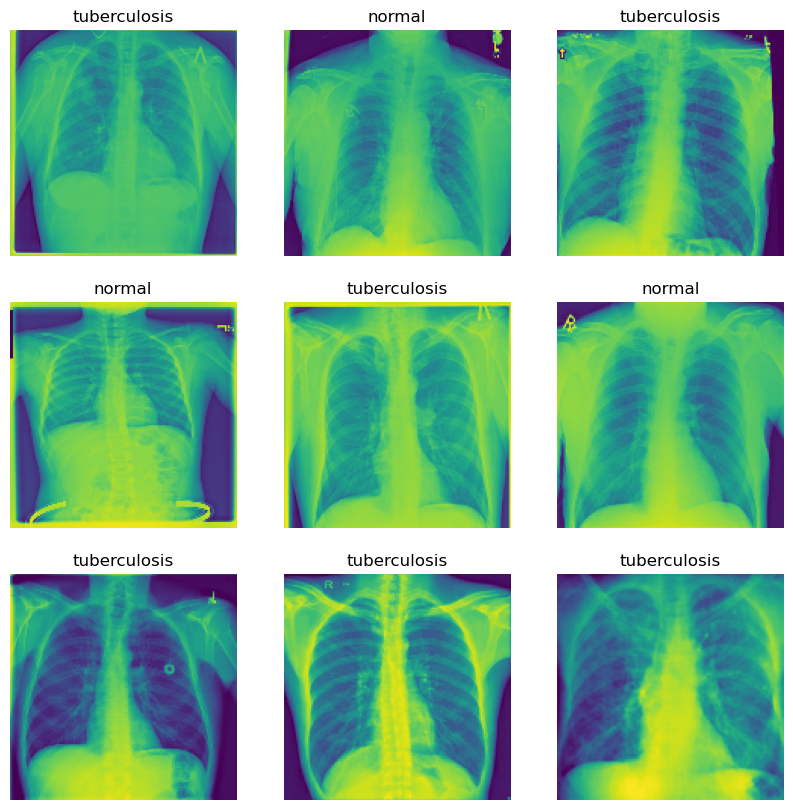

In [26]:
plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(np.squeeze(images[i].numpy().astype('uint8')))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis('off')
        


In [27]:
train_ds = train_ds.cache().shuffle(buffer_size).prefetch(buffer_size = autotune)
val_ds = val_ds.cache().prefetch(buffer_size = autotune)
test_ds = test_ds.cache().prefetch(buffer_size = autotune)


In [31]:
def conv_block(filters, inputs):
    x = tf.keras.layers.SeparableConv2D(filters, 3 , padding = 'same', activation = 'relu')(inputs)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.SeparableConv2D(filters, 3, padding = 'same', activation = 'relu')(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x = tf.keras.layers.SeparableConv2D(filters, 3, padding = 'same', activation = 'relu')(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    x =tf.keras.layers.batch_normalization()(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    return x

def dense_block(units, dropout_rate, inputs):
    x = tf.keras.layers.Dense(units, activation = 'relu')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    return x
    

In [35]:
def build_model():
    inputs = tf.keras.Input(shape = (img_size[0], img_size[1], img_size[2], 1))
    x = tf.keras.layers.Rescaling(1./255)(inputs)
    x = tf.keras.layers.Conv2D(32, 3, padding = 'same', activation = 'relu')(x)
    x = tf.keras.layers.Conv2D(32, 3, padding = 'same', activation = 'relu')(x)
    x = tf.keras.layers.Conv2D(32, 3, padding = 'same', activation = 'relu')(x)
    x = tf.keras.layers.MaxPooling2D()(x)
    
    x = conv_block(32, x)
    x = conv_block(64, x)
    x = conv_block(128, x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = conv_block(256,x)
    x = tf.keras.Dropout(0.5)(x)

    x = tf.keras.layers.Flatten()(x)
    x = dense_block(512, 0.7, x)
    x = dense_block(256, 0.5, x)
    x = dense_block(128, 0.3, x)

    outputs = tf.keras.layers.Dense(3, activation = 'sigmoid')(x)
    model = tf.keras.Model(inputs, outputs)
    return model


